In [1]:
import numpy as np
import matplotlib.pyplot as plt

from impulse import PTSampler, BirthDeathProductSpace
from impulse import model_visitation_stats, bayes_factor_from_chain

%load_ext autoreload
%autoreload 2

## RJMCMC Model Selection: 1 to 3 Sinusoids

This example uses `BirthDeathProductSpace` and `PTSampler.from_product_space()` to
perform trans-dimensional model selection with formally correct birth/death
proposals. Compare with `product_space_sinusoids.ipynb` which does the
same thing with hand-written proposals.

**What the RJMCMC API handles for you:**
- Birth/death proposals with correct Hastings ratios
- Model-index jump and source-swap proposals
- Parameter groups (one per source, model index excluded)
- Prior enforcement on all source parameters (active + inactive)
- Initial position drawing from the prior

### Generate synthetic data

Two sinusoids buried in Gaussian noise.

In [2]:
# Prior bounds
A_MIN, A_MAX = 0.0, 5.0
F_MIN, F_MAX = 0.0, 3.0
PHI_MIN, PHI_MAX = 0.0, np.pi

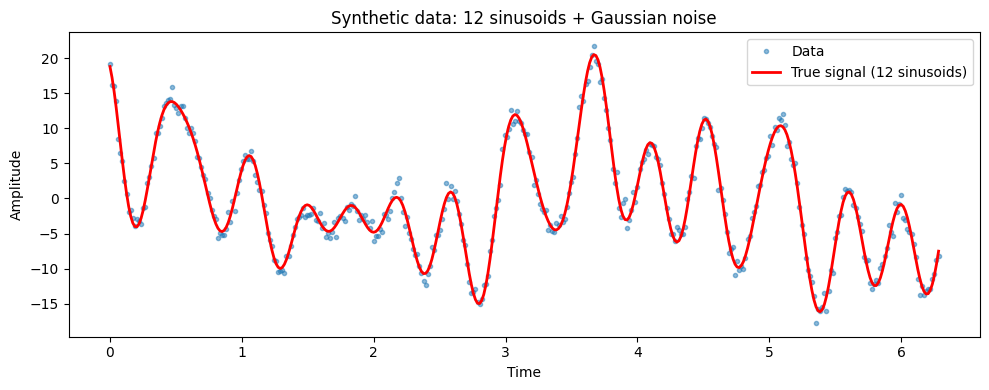

In [3]:
rng = np.random.default_rng(42)
num_sources_true = 12

N_pts = 400
t = np.linspace(0, 2 * np.pi, N_pts)
sigma = 1.0

A_true = np.random.uniform(A_MIN, A_MAX, size=num_sources_true)
f_true = np.random.uniform(F_MIN, F_MAX, size=num_sources_true)
phi_true = np.random.uniform(PHI_MIN, PHI_MAX, size=num_sources_true)
n_true = len(A_true)

signal = np.zeros(N_pts)
for A, f, phi in zip(A_true, f_true, phi_true):
    signal += A * np.sin(2 * np.pi * f * t + phi)

data = signal + sigma * rng.standard_normal(N_pts)

plt.figure(figsize=(10, 4))
plt.plot(t, data, '.', alpha=0.5, label='Data')
plt.plot(t, signal, 'r-', lw=2, label=f'True signal ({n_true} sinusoids)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.title(f'Synthetic data: {n_true} sinusoids + Gaussian noise')
plt.tight_layout()

### Define the model

The user provides:
1. A **likelihood** that uses the first `(nmodel+1) * num_params` parameters
2. A **prior** that checks bounds on **all** source parameters
3. A **draw function** that samples one source's parameters from the prior

The RJMCMC machinery handles everything else.

In [4]:
MAX_SOURCES = 20
NUM_PARAMS = 3  # (amplitude, frequency, phase) per source




def source_prior_draw(rng):
    """Draw one source's parameters from the prior."""
    return np.array([
        rng.uniform(A_MIN, A_MAX),
        rng.uniform(F_MIN, F_MAX),
        rng.uniform(PHI_MIN, PHI_MAX),
    ])


def log_prior(params):
    """Uniform prior on ALL source parameters.

    BirthDeathProductSpace passes all num_sources * num_params parameters
    to this function, so bounds are enforced on inactive sources too.
    """
    n_sources = len(params) // NUM_PARAMS
    for i in range(n_sources):
        A = params[i * NUM_PARAMS]
        f = params[i * NUM_PARAMS + 1]
        phi = params[i * NUM_PARAMS + 2]
        if not (A_MIN <= A <= A_MAX):
            return -np.inf
        if not (F_MIN <= f <= F_MAX):
            return -np.inf
        if not (PHI_MIN <= phi <= PHI_MAX):
            return -np.inf
    return 0.0


def log_likelihood(params):
    """Gaussian likelihood using active sinusoidal components."""
    n_sources = len(params) // NUM_PARAMS
    model = np.zeros(N_pts)
    for i in range(n_sources):
        A = params[i * NUM_PARAMS]
        f = params[i * NUM_PARAMS + 1]
        phi = params[i * NUM_PARAMS + 2]
        model += A * np.sin(2 * np.pi * f * t + phi)
    return -0.5 * np.sum(((data - model) / sigma) ** 2)

### Build the RJMCMC sampler

Two lines: create the product space, then build the sampler.

`PTSampler.from_product_space()` automatically registers birth, death,
model-index jump, and source-swap proposals alongside the standard
AM / SCAM / DE proposals.

In [5]:
space = BirthDeathProductSpace(
    loglikelihood=log_likelihood,
    logprior=log_prior,
    num_sources=MAX_SOURCES,
    num_params=NUM_PARAMS,
    source_prior_draw=source_prior_draw,
)

sampler = PTSampler.from_product_space(
    space,
    ntemps=15,
    inf_temp=True,
    seed=42,
    outdir='./chains_rjmcmc',
)

x0 = space.draw_initial_position(rng, nmodel=1)

print(f"Parameter space: {space.ndim} dimensions")
print(f"  {MAX_SOURCES} sources x {NUM_PARAMS} params + 1 model index")
print(f"Groups: {space.get_default_groups()}")
print(f"Initial nmodel = {int(x0[-1])} ({int(x0[-1]) + 1} sinusoid(s))")

Parameter space: 61 dimensions
  20 sources x 3 params + 1 model index
Groups: [[0, 1, 2], [3, 4, 5], [6, 7, 8], [9, 10, 11], [12, 13, 14], [15, 16, 17], [18, 19, 20], [21, 22, 23], [24, 25, 26], [27, 28, 29], [30, 31, 32], [33, 34, 35], [36, 37, 38], [39, 40, 41], [42, 43, 44], [45, 46, 47], [48, 49, 50], [51, 52, 53], [54, 55, 56], [57, 58, 59]]
Initial nmodel = 1 (2 sinusoid(s))


In [ ]:
sampler.sample(x0, num_iterations=100_000)

Sampling:  17%|█▋        | 17301/100000 [00:31<02:29, 553.98it/s]

### Model selection results

In [ ]:
chains = sampler.load_chain()
cold_chain = chains['samples'][0]
cold_lnlike = chains['lnlike'][0]
burn = 30_000

# Model posterior probabilities (one-liner)
probs = space.model_posterior_probs(cold_chain, burn=burn)

print("=== Model Selection ===")
for k in range(MAX_SOURCES):
    print(f"  P({k + 1} sinusoid{'s' if k > 0 else ' '}) = {probs[k]:.3f}")

preferred = np.argmax(probs)
print(f"\nTrue number of sinusoids: {n_true}")
print(f"Most probable model:      {preferred + 1} sinusoid(s)")

=== Model Selection ===
  P(1 sinusoid ) = 0.000
  P(2 sinusoids) = 0.785
  P(3 sinusoids) = 0.215

True number of sinusoids: 2
Most probable model:      2 sinusoid(s)


### RJMCMC diagnostics

The `model_visitation_stats` function provides posterior probabilities,
visit counts, the transition matrix between models, and mean dwell times.
`bayes_factor_from_chain` gives pairwise Bayes factors.

In [ ]:
stats = model_visitation_stats(cold_chain, num_models=MAX_SOURCES, burn=burn)

print("=== Visitation Statistics ===")
print(f"Visit counts:    {stats['visit_counts']}")
print(f"Mean dwell times: {stats['mean_dwell_times']}")
print(f"\nTransition matrix (row = from, col = to):")
labels = [f"{k+1} src" for k in range(MAX_SOURCES)]
header = "         " + "  ".join(f"{l:>7s}" for l in labels)
print(header)
for i in range(MAX_SOURCES):
    row = "  ".join(f"{stats['transition_matrix'][i, j]:7.4f}" for j in range(MAX_SOURCES))
    print(f"  {labels[i]:>5s}   {row}")

print(f"\n=== Bayes Factors ===")
for i in range(MAX_SOURCES):
    for j in range(i + 1, MAX_SOURCES):
        bf = bayes_factor_from_chain(cold_chain, i, j, burn=burn)
        print(f"  B({i+1} vs {j+1}) = {bf:.2f}")

=== Visitation Statistics ===
Visit counts:    [    0. 54936. 15064.]
Mean dwell times: [0.         6.41700736 1.75940201]

Transition matrix (row = from, col = to):
           1 src    2 src    3 src
  1 src    0.0000   0.0000   0.0000
  2 src    0.0000   0.8442   0.1558
  3 src    0.0000   0.5683   0.4317

=== Bayes Factors ===
  B(1 vs 2) = 0.00
  B(1 vs 3) = 0.00
  B(2 vs 3) = 3.65


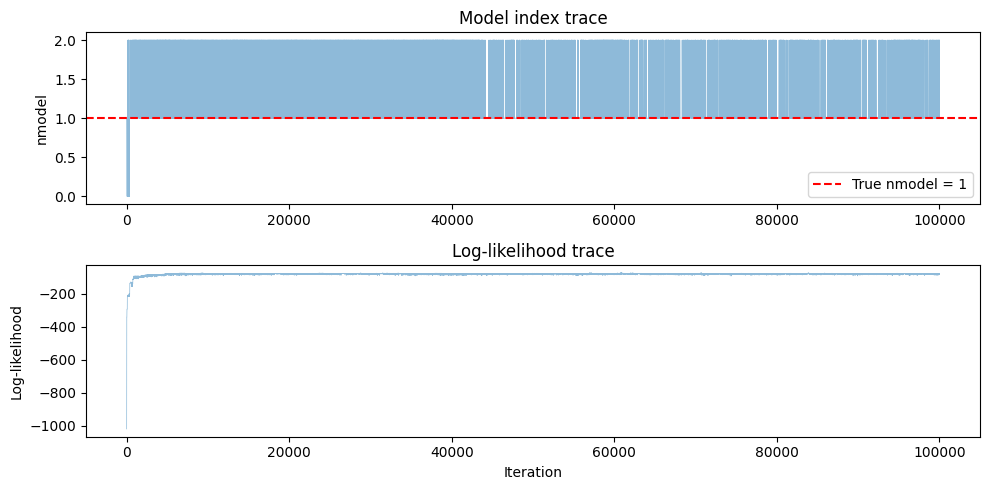

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].plot(cold_chain[:, -1], alpha=0.5, lw=0.5)
axes[0].axhline(n_true - 1, color='r', ls='--', label=f'True nmodel = {n_true - 1}')
axes[0].set_ylabel('nmodel')
axes[0].set_title('Model index trace')
axes[0].legend()

axes[1].plot(cold_lnlike, alpha=0.5, lw=0.5)
axes[1].set_ylabel('Log-likelihood')
axes[1].set_xlabel('Iteration')
axes[1].set_title('Log-likelihood trace')
plt.tight_layout()

### Parameter estimates for the preferred model

In [ ]:
nmodel_samples = np.rint(cold_chain[burn:, -1]).astype(int)
mask = nmodel_samples == preferred
preferred_samples = cold_chain[burn:][mask]

true_vals = [A_true, f_true, phi_true]
param_labels = ['A', 'f', 'phi']

print(f"=== Parameter estimates ({preferred + 1}-sinusoid model) ===")
for i in range(preferred + 1):
    print(f"\n  Source {i + 1}:")
    for j, name in enumerate(param_labels):
        idx = i * NUM_PARAMS + j
        med = np.median(preferred_samples[:, idx])
        lo = np.percentile(preferred_samples[:, idx], 16)
        hi = np.percentile(preferred_samples[:, idx], 84)
        line = f"    {name:>3s} = {med:.3f}  [{lo:.3f}, {hi:.3f}]"
        if i < n_true:
            line += f"  (true: {true_vals[j][i]:.3f})"
        print(line)

=== Parameter estimates (2-sinusoid model) ===

  Source 1:
      A = 2.177  [1.372, 2.544]  (true: 2.500)
      f = 0.809  [0.797, 2.097]  (true: 0.800)
    phi = 0.752  [0.493, 1.922]  (true: 0.500)

  Source 2:
      A = 1.729  [1.377, 2.538]  (true: 1.200)
      f = 2.079  [0.797, 2.097]  (true: 2.100)
    phi = 1.457  [0.495, 1.922]  (true: 1.800)


### Best-fit model vs data

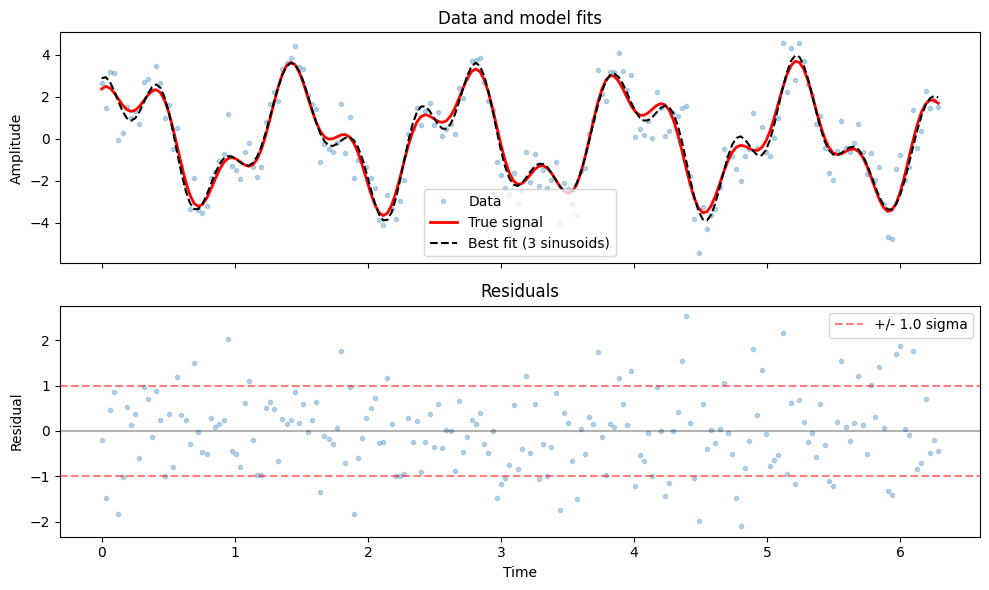

In [ ]:
best_idx = np.argmax(cold_lnlike[burn:]) + burn
best_params = cold_chain[best_idx]
best_nmodel = int(np.rint(best_params[-1]))

best_model = np.zeros(N_pts)
for i in range(best_nmodel + 1):
    A = best_params[i * NUM_PARAMS]
    f = best_params[i * NUM_PARAMS + 1]
    phi = best_params[i * NUM_PARAMS + 2]
    best_model += A * np.sin(2 * np.pi * f * t + phi)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, data, '.', alpha=0.3, label='Data')
axes[0].plot(t, signal, 'r-', lw=2, label='True signal')
axes[0].plot(t, best_model, 'k--', lw=1.5, label=f'Best fit ({best_nmodel + 1} sinusoids)')
axes[0].legend()
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Data and model fits')

axes[1].plot(t, data - best_model, '.', alpha=0.3)
axes[1].axhline(0, color='k', ls='-', alpha=0.3)
axes[1].axhline(sigma, color='r', ls='--', alpha=0.5, label=f'+/- {sigma} sigma')
axes[1].axhline(-sigma, color='r', ls='--', alpha=0.5)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')
axes[1].legend()
plt.tight_layout()

### Prior enforcement check

`BirthDeathProductSpace` enforces the prior on all source parameters
(including inactive ones) automatically.

In [ ]:
print("=== Prior enforcement check ===")
post_burn = cold_chain[burn:]
all_ok = True
for i in range(MAX_SOURCES):
    A_vals = post_burn[:, i * NUM_PARAMS]
    f_vals = post_burn[:, i * NUM_PARAMS + 1]
    phi_vals = post_burn[:, i * NUM_PARAMS + 2]
    violations = (
        np.any(A_vals < A_MIN) or np.any(A_vals > A_MAX)
        or np.any(f_vals < F_MIN) or np.any(f_vals > F_MAX)
        or np.any(phi_vals < PHI_MIN) or np.any(phi_vals > PHI_MAX)
    )
    status = 'VIOLATION' if violations else 'OK'
    if violations:
        all_ok = False
    print(
        f"  Source {i + 1}:  "
        f"A in [{A_vals.min():.3f}, {A_vals.max():.3f}],  "
        f"f in [{f_vals.min():.3f}, {f_vals.max():.3f}],  "
        f"phi in [{phi_vals.min():.3f}, {phi_vals.max():.3f}]  "
        f"- {status}"
    )

nmodel_vals = np.rint(post_burn[:, -1]).astype(int)
valid = np.all((nmodel_vals >= 0) & (nmodel_vals < MAX_SOURCES))
if not valid:
    all_ok = False
print(f"  nmodel:   all in {{0..{MAX_SOURCES - 1}}} = {valid}")
print(f"\nAll priors respected: {all_ok}")

=== Prior enforcement check ===
  Source 1:  A in [0.000, 2.979],  f in [0.007, 2.997],  phi in [0.002, 3.138]  - OK
  Source 2:  A in [0.000, 2.841],  f in [0.007, 2.989],  phi in [0.011, 3.138]  - OK
  Source 3:  A in [0.000, 4.999],  f in [0.001, 3.000],  phi in [0.000, 3.141]  - OK
  nmodel:   all in {0..2} = True

All priors respected: True
